In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from utils.model_architectures import build_experimental_model
from utils.plots import style_plot_fonts, poppins_light, poppins_bold, title_fontsize, subtitle_fontsize, tick_fontsize, label_fontsize, cmap, cmap_x85

from config import IMG_SIZE, BATCH_SIZE, CLASSES, SEED
from utils.preprocess_data import get_garbage_datasets

from highlight_text import (
    ax_text, 
    fig_text
)
from drawarrow import fig_arrow
from pypalettes import load_cmap

In [2]:
os.makedirs('../plots', exist_ok=True)

In [3]:
cmap = load_cmap("Abbott")

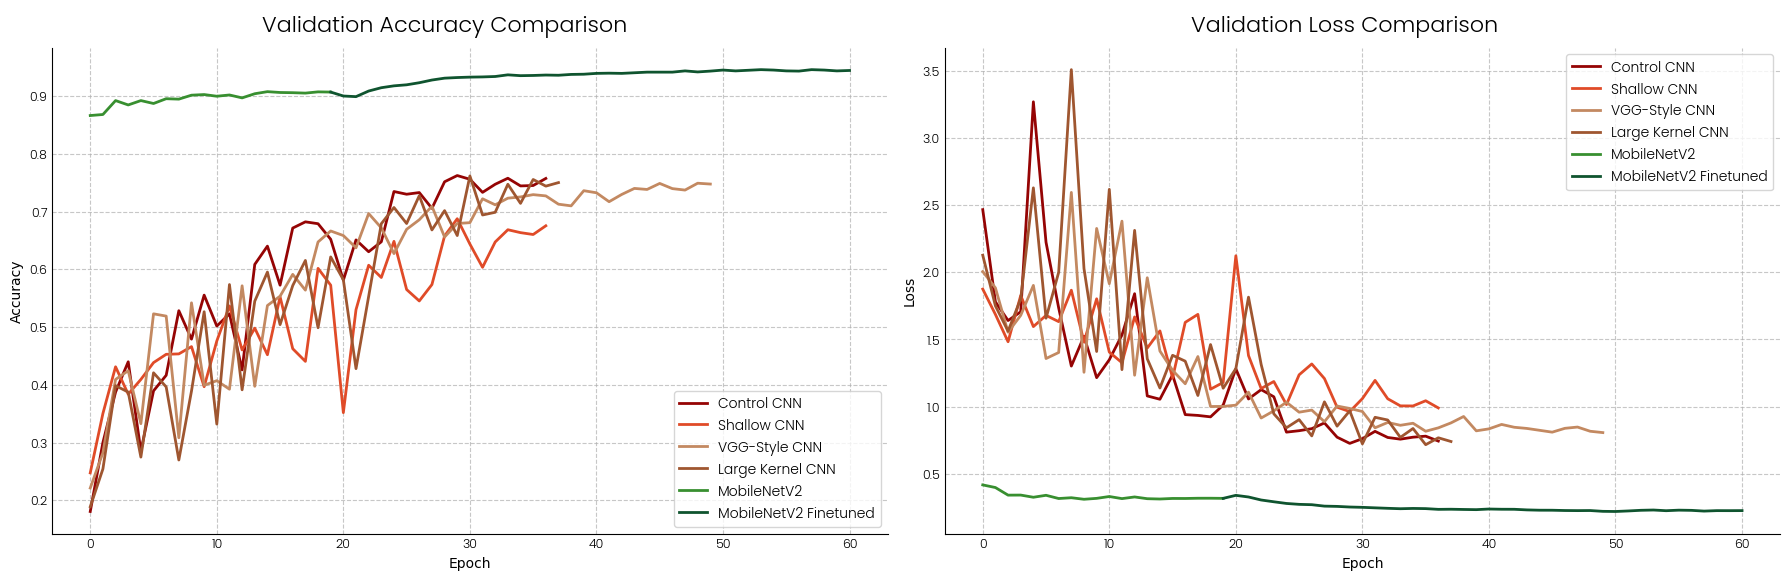

In [4]:
# Define the models and where to find their CSV logs
# Update the paths if your files are named differently!
models_to_plot = {
    'Control CNN': '../logs/control_history.csv',
    'Shallow CNN': '../logs/shallow_history.csv',
    'VGG-Style CNN': '../logs/vgg_style_history.csv',
    'Large Kernel CNN': '../logs/large_kernel_history.csv',
    'MobileNetV2': '../logs/mobilenet_v2_history.csv',
    'MobileNetV2 Finetuned': '../logs/mobilenet_v2_finetuned_history.csv'
}

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Variables to remember where Phase 1 ended
phase1_length = 0
phase1_last_acc = None
phase1_last_loss = None

for idx, (display_name, csv_path) in enumerate(models_to_plot.items()):
    if os.path.exists(csv_path):
        history_df = pd.read_csv(csv_path)
        
        # 1. SPECIAL LOGIC FOR FINETUNED MODEL
        if display_name == 'MobileNetV2 Finetuned' and phase1_length > 0:
            # Shift X-axis so it starts exactly where Phase 1 ended
            x_values = range(phase1_length - 1, phase1_length + len(history_df))
            
            # Prepend the final point of Phase 1 so the lines physically touch
            y_train_acc = [phase1_last_acc] + history_df['accuracy'].tolist()
            y_train_loss = [phase1_last_loss] + history_df['loss'].tolist()

            y_acc = [phase1_last_acc] + history_df['val_accuracy'].tolist()
            y_loss = [phase1_last_loss] + history_df['val_loss'].tolist()
            
        # 2. STANDARD LOGIC FOR ALL OTHER MODELS
        else:
            x_values = history_df.index
            y_acc = history_df['val_accuracy']
            y_loss = history_df['val_loss']
            y_train_acc = history_df['accuracy']
            y_train_loss = history_df['loss']

            # If this is the base MobileNet, save its final state before moving to the next loop
            if display_name == 'MobileNetV2':
                phase1_length = len(history_df)
                phase1_last_acc = history_df['val_accuracy'].iloc[-1]
                phase1_last_loss = history_df['val_loss'].iloc[-1]

        # Plot Accuracy
        ax[0].plot(x_values, y_acc, label=display_name, color=cmap(idx), linewidth=2)
        
        # Plot Loss
        ax[1].plot(x_values, y_loss, label=display_name, color=cmap(idx), linewidth=2)
        
    else:
        print(f"⚠️ Warning: Could not find {csv_path}. Skipping {display_name}.")

style_plot_fonts(ax[0])
style_plot_fonts(ax[1])

# Format Accuracy Plot
fig_text(
    x=0.25, y=0.95, ha='center',
    s=f"Validation Accuracy Comparison", 
    fontsize=16, 
    font=poppins_light,
    ax=ax[0]
)
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='lower right', prop=poppins_light)
ax[0].grid(True, linestyle='--', alpha=0.7)

# Format Loss Plot
fig_text(
    x=0.75, y=0.95, ha='center',
    s=f"Validation Loss Comparison", 
    fontsize=16, 
    font=poppins_light,
    ax=ax[1]
)
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper right', prop=poppins_light)
ax[1].grid(True, linestyle='--', alpha=0.7)    

plt.tight_layout()
plt.savefig('../plots/learning-comparison.png')
plt.show()

/var/folders/k0/426ngj994pqf16x0xd47lrx40000gn/T/ipykernel_61075/4261780839.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx][0].legend(loc='lower right', prop=poppins_light)
/var/folders/k0/426ngj994pqf16x0xd47lrx40000gn/T/ipykernel_61075/4261780839.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx][1].legend(loc='upper right', prop=poppins_light)
/var/folders/k0/426ngj994pqf16x0xd47lrx40000gn/T/ipykernel_61075/4261780839.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx][0].legend(loc='lower right', prop=poppins_light)
/var/folders/k0/426ngj994pqf16x0xd47lrx40000gn/T/ipykernel_61075

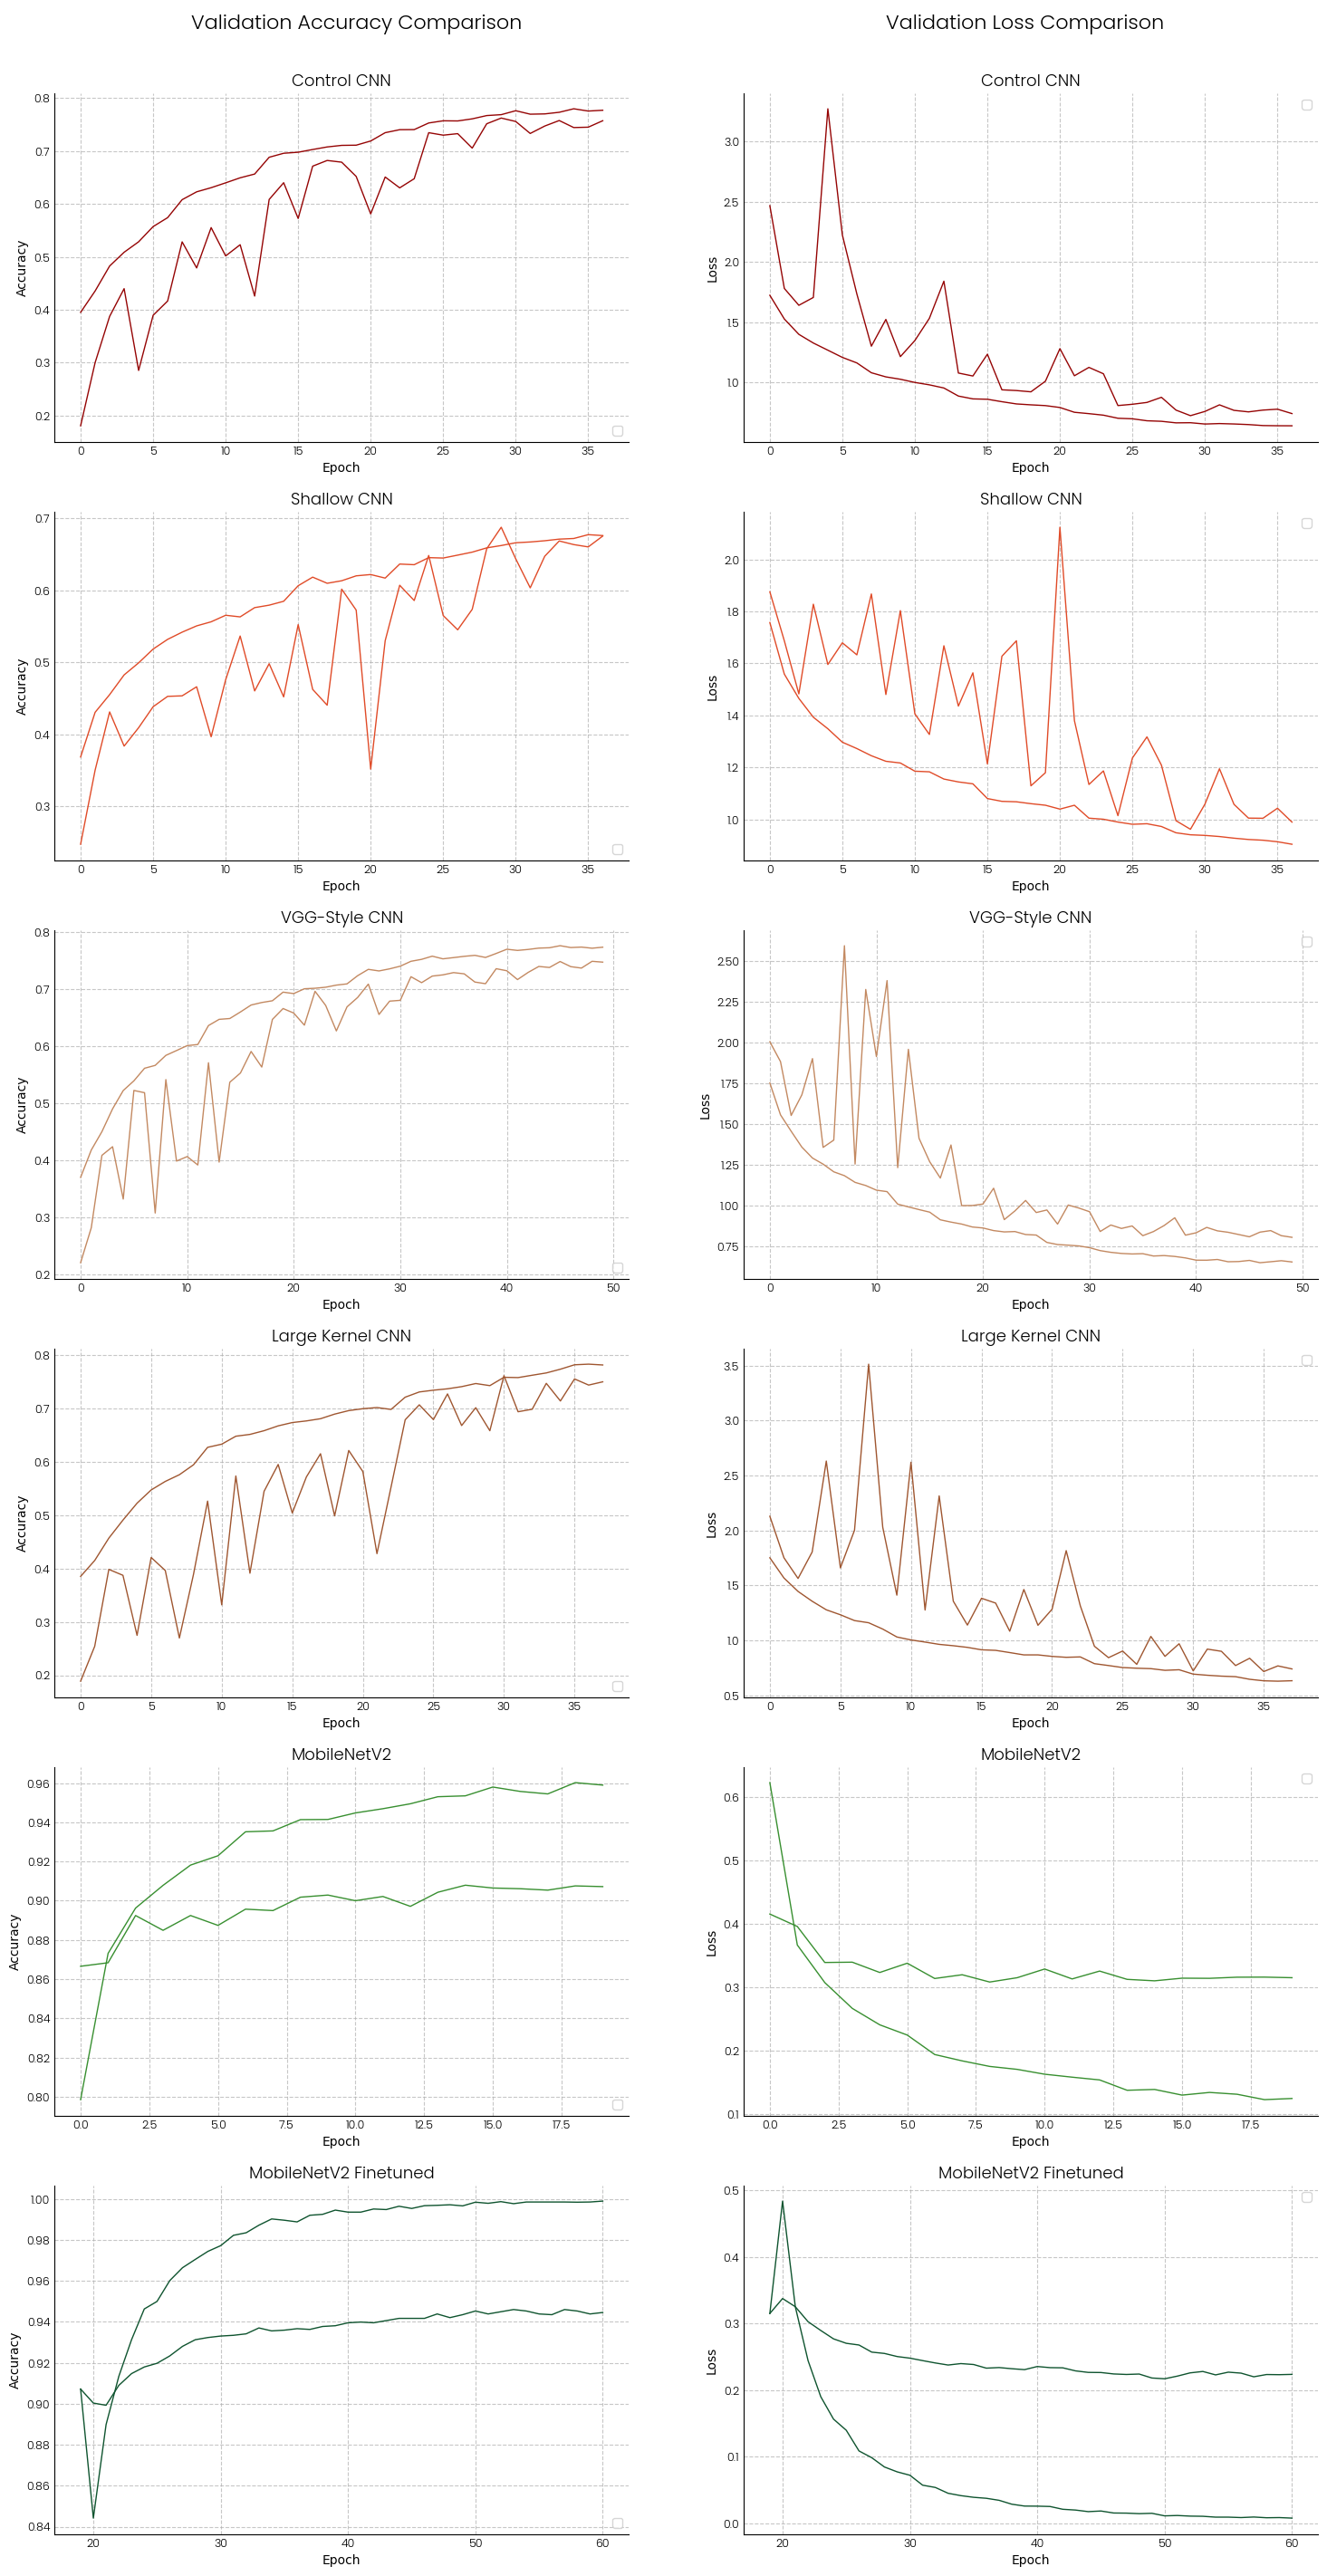

In [10]:
# Define the models and where to find their CSV logs
# Update the paths if your files are named differently!
models_to_plot = {
    'Control CNN': '../logs/control_history.csv',
    'Shallow CNN': '../logs/shallow_history.csv',
    'VGG-Style CNN': '../logs/vgg_style_history.csv',
    'Large Kernel CNN': '../logs/large_kernel_history.csv',
    'MobileNetV2': '../logs/mobilenet_v2_history.csv',
    'MobileNetV2 Finetuned': '../logs/mobilenet_v2_finetuned_history.csv'
}

fig, ax = plt.subplots(6, 2, figsize=(18, 35))

# Variables to remember where Phase 1 ended
phase1_length = 0
phase1_last_acc = None
phase1_last_loss = None

for idx, (display_name, csv_path) in enumerate(models_to_plot.items()):
    if os.path.exists(csv_path):
        history_df = pd.read_csv(csv_path)
        
        # 1. SPECIAL LOGIC FOR FINETUNED MODEL
        if display_name == 'MobileNetV2 Finetuned' and phase1_length > 0:
            # Shift X-axis so it starts exactly where Phase 1 ended
            x_values = range(phase1_length - 1, phase1_length + len(history_df))
            
            # Prepend the final point of Phase 1 so the lines physically touch
            y_train_acc = [phase1_last_acc] + history_df['accuracy'].tolist()
            y_train_loss = [phase1_last_loss] + history_df['loss'].tolist()

            y_acc = [phase1_last_acc] + history_df['val_accuracy'].tolist()
            y_loss = [phase1_last_loss] + history_df['val_loss'].tolist()
            
        # 2. STANDARD LOGIC FOR ALL OTHER MODELS
        else:
            x_values = history_df.index
            y_acc = history_df['val_accuracy']
            y_loss = history_df['val_loss']
            y_train_acc = history_df['accuracy']
            y_train_loss = history_df['loss']

            # If this is the base MobileNet, save its final state before moving to the next loop
            if display_name == 'MobileNetV2':
                phase1_length = len(history_df)
                phase1_last_acc = history_df['val_accuracy'].iloc[-1]
                phase1_last_loss = history_df['val_loss'].iloc[-1]

        style_plot_fonts(ax[idx][0])
        style_plot_fonts(ax[idx][1])
        ax[idx][0].set_title(display_name, font=poppins_light, fontsize=13)
        ax[idx][1].set_title(display_name, font=poppins_light, fontsize=13)

        ax[idx][0].set_ylabel('Accuracy')
        ax[idx][0].set_xlabel('Epoch')
        ax[idx][0].legend(loc='lower right', prop=poppins_light)
        ax[idx][0].grid(True, linestyle='--', alpha=0.7)

        ax[idx][1].set_ylabel('Loss')
        ax[idx][1].set_xlabel('Epoch')
        ax[idx][1].legend(loc='upper right', prop=poppins_light)
        ax[idx][1].grid(True, linestyle='--', alpha=0.7)    

        # Plot Accuracy
        ax[idx][0].plot(x_values, y_acc, label=display_name, color=cmap(idx), linewidth=1)
        ax[idx][0].plot(x_values, y_train_acc, label=display_name, color=cmap(idx), linewidth=1)
        
        # Plot Loss
        ax[idx][1].plot(x_values, y_loss, label=display_name, color=cmap(idx), linewidth=1)
        ax[idx][1].plot(x_values, y_train_loss, label=display_name, color=cmap(idx), linewidth=1)
        
    else:
        print(f"⚠️ Warning: Could not find {csv_path}. Skipping {display_name}.")

# ax[idx][0].set_ylabel('Accuracy')
# ax[idx][0].set_xlabel('Epoch')
# ax[idx][0].legend(loc='lower right', prop=poppins_light)
# ax[idx][0].grid(True, linestyle='--', alpha=0.7)

# ax[idx][1].set_ylabel('Loss')
# ax[idx][1].set_xlabel('Epoch')
# ax[idx][1].legend(loc='upper right', prop=poppins_light)
# ax[idx][1].grid(True, linestyle='--', alpha=0.7)    

# Format Accuracy Plot
fig_text(
    x=0.31, y=0.905, ha='center',
    s=f"Validation Accuracy Comparison", 
    fontsize=16, 
    font=poppins_light,
    ax=ax[0][0]
)

# Format Loss Plot
fig_text(
    x=0.72, y=0.905, ha='center',
    s=f"Validation Loss Comparison", 
    fontsize=16, 
    font=poppins_light,
    ax=ax[0][1]
)

# plt.tight_layout()
plt.savefig('../plots/learning-comparison-all.png')
plt.show()

In [6]:
cmap_heatmap = load_cmap("sPBIOr")

In [7]:
print("1. Rebuilding Validation Dataset...")
image_categories_path = '../data/images'

# Re-instantiate the datasets (we only really need val_ds, but the function returns both)
train_ds, val_ds, class_names = get_garbage_datasets(
    data_dir=image_categories_path, 
    batch_size=BATCH_SIZE, 
    img_size=IMG_SIZE, 
    seed=SEED,
    model_type='custom' 
)
print("Dataset rebuilt successfully!")


# Define the Evaluation Plotter
def evaluate_and_plot(y_true, y_pred, class_names, model_name="Model"):
    # Ensure the directory exists
    plots_dir = '../plots/'
    os.makedirs(plots_dir, exist_ok=True)
    
    cm = confusion_matrix(y_true, y_pred)
    
    # FIX: Changed from (1, 2) to a single subplot so you don't get an empty blank chart next to it
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap=cmap_heatmap, 
        xticklabels=class_names, 
        yticklabels=class_names, 
        linewidths=0.5, 
        ax=ax, 
        cbar=False
    )

    ax.set_ylabel('Predicted Label', fontsize=12, labelpad=10)
    ax.set_xlabel('True Label', fontsize=12, labelpad=20)
    # ax.set_title(f'Confusion Matrix: {model_name}', fontsize=title_fontsize)
    fig_text(
        x=0.5, y=0.9,            # x=0.5 is exactly in the middle of the heatmap itself
        ha='center', va='bottom', # Centers the text structurally
        s=f"Confusion Matrix: <{model_name.capitalize()}>", 
        fontsize=16, 
        fontproperties=poppins_light,
        highlight_textprops=[{
            "color": cmap_x85(5),
            "fontproperties": poppins_bold,
        }],
        ax=ax                     # Binds the text position to the chart's boundaries
    )

    style_plot_fonts(ax)
    
    # Clean the model name for the filename (lowercase, replaces spaces/special chars)
    safe_filename = model_name.lower().replace(" ", "_").replace("/", "_")
    save_path = os.path.join(plots_dir, f'confusion_matrix_{safe_filename}.png')
    
    # Save the figure BEFORE plt.show() (showing it clears the current figure state)
    plt.savefig(save_path, bbox_inches='tight')
    print(f"📉 Saved confusion matrix plot to: {save_path}")
    
    plt.show()

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    
    metrics_df = pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [round(accuracy, 4)],
        'Macro Precision': [round(precision, 4)],
        'Macro Recall': [round(recall, 4)],
        'Macro F1-Score': [round(f1, 4)]
    })
    
    print(f"\n--- Detailed Classification Report: {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return metrics_df

1. Rebuilding Validation Dataset...
Found 13901 files belonging to 6 classes.
Using 11121 files for training.


2026-05-30 20:02:33.174009: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-30 20:02:33.174046: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-30 20:02:33.174049: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-30 20:02:33.174066: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-30 20:02:33.174075: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 13901 files belonging to 6 classes.
Using 2780 files for validation.
Dataset rebuilt successfully!


Extracting validation images and labels...


2026-05-30 20:02:33.897272: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loaded 2780 validation images.

🔍 EVALUATING: Control


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for control.
Generating predictions...
 1/87 ━━━━━━━━━━━━━━━━━━━━ 25s 295ms/step

2026-05-30 20:02:35.178688: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
📉 Saved confusion matrix plot to: ../plots/confusion_matrix_control.png


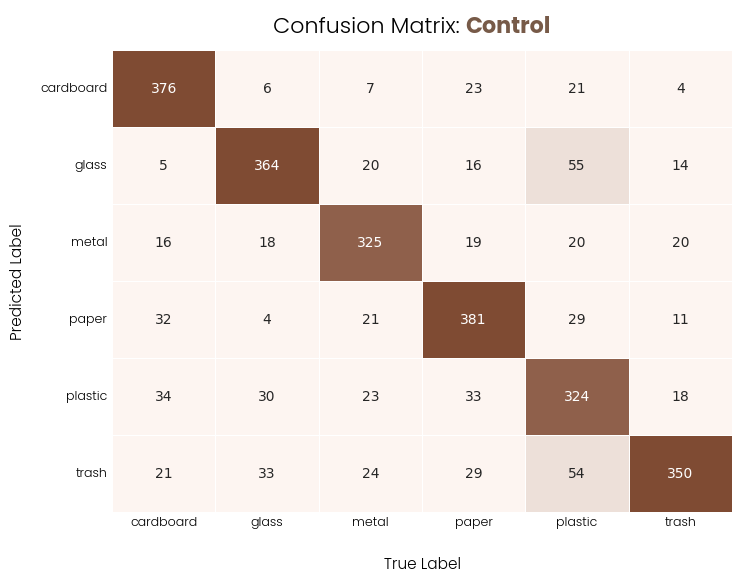


--- Detailed Classification Report: control ---
              precision    recall  f1-score   support

   cardboard       0.78      0.86      0.82       437
       glass       0.80      0.77      0.78       474
       metal       0.77      0.78      0.78       418
       paper       0.76      0.80      0.78       478
     plastic       0.64      0.70      0.67       462
       trash       0.84      0.68      0.75       511

    accuracy                           0.76      2780
   macro avg       0.77      0.76      0.76      2780
weighted avg       0.77      0.76      0.76      2780


🔍 EVALUATING: Shallow


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for shallow.
Generating predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
📉 Saved confusion matrix plot to: ../plots/confusion_matrix_shallow.png


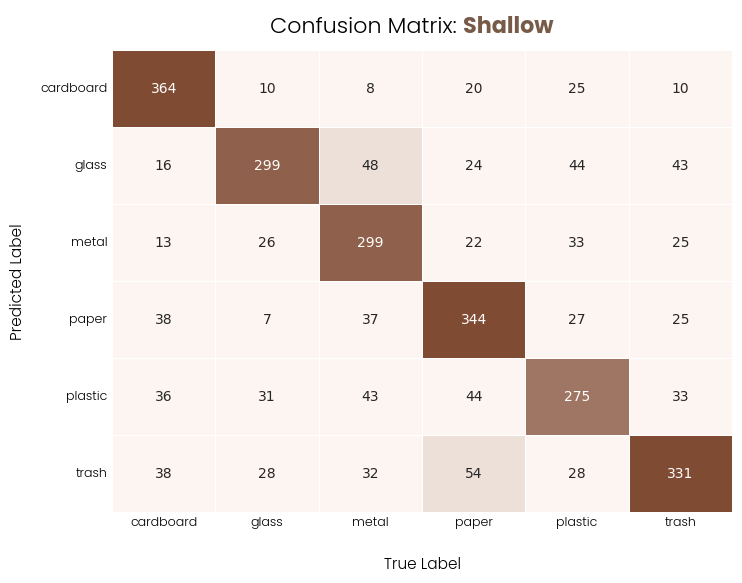


--- Detailed Classification Report: shallow ---
              precision    recall  f1-score   support

   cardboard       0.72      0.83      0.77       437
       glass       0.75      0.63      0.68       474
       metal       0.64      0.72      0.68       418
       paper       0.68      0.72      0.70       478
     plastic       0.64      0.60      0.62       462
       trash       0.71      0.65      0.68       511

    accuracy                           0.69      2780
   macro avg       0.69      0.69      0.69      2780
weighted avg       0.69      0.69      0.69      2780


🔍 EVALUATING: Vgg_style


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for vgg_style.
Generating predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step
📉 Saved confusion matrix plot to: ../plots/confusion_matrix_vgg_style.png


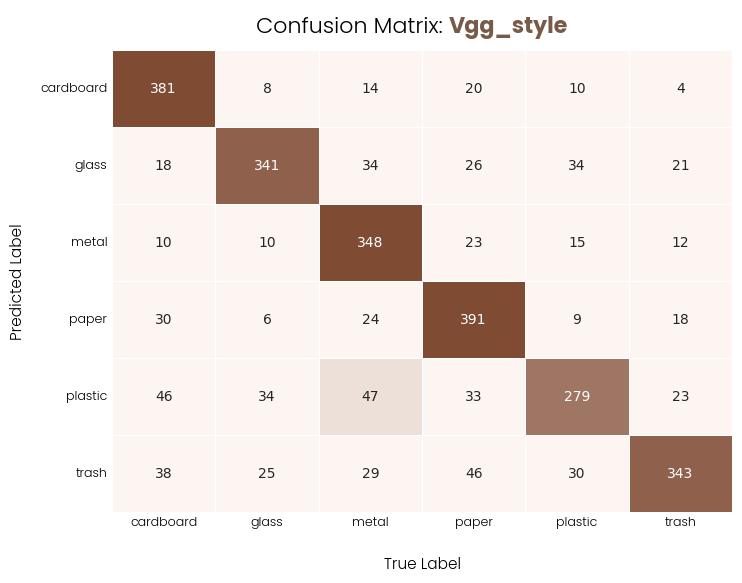


--- Detailed Classification Report: vgg_style ---
              precision    recall  f1-score   support

   cardboard       0.73      0.87      0.79       437
       glass       0.80      0.72      0.76       474
       metal       0.70      0.83      0.76       418
       paper       0.73      0.82      0.77       478
     plastic       0.74      0.60      0.67       462
       trash       0.81      0.67      0.74       511

    accuracy                           0.75      2780
   macro avg       0.75      0.75      0.75      2780
weighted avg       0.75      0.75      0.75      2780


🔍 EVALUATING: Large_kernel


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for large_kernel.
Generating predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
📉 Saved confusion matrix plot to: ../plots/confusion_matrix_large_kernel.png


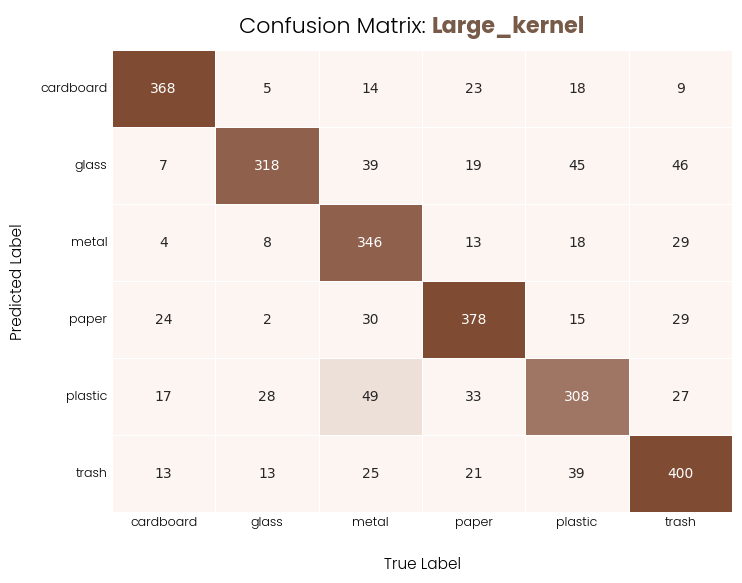


--- Detailed Classification Report: large_kernel ---
              precision    recall  f1-score   support

   cardboard       0.85      0.84      0.85       437
       glass       0.85      0.67      0.75       474
       metal       0.69      0.83      0.75       418
       paper       0.78      0.79      0.78       478
     plastic       0.70      0.67      0.68       462
       trash       0.74      0.78      0.76       511

    accuracy                           0.76      2780
   macro avg       0.77      0.76      0.76      2780
weighted avg       0.77      0.76      0.76      2780


🔍 EVALUATING: Mobilenet_v2


/Users/kvbek/Documents/projects/garbage-sorting-model/src/utils/model_architectures.py:101: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for mobilenet_v2.
Generating predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step
📉 Saved confusion matrix plot to: ../plots/confusion_matrix_mobilenet_v2.png


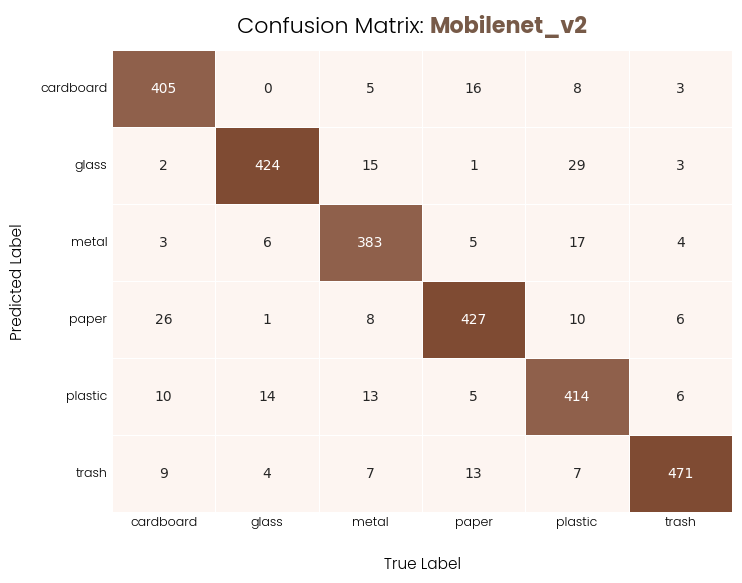


--- Detailed Classification Report: mobilenet_v2 ---
              precision    recall  f1-score   support

   cardboard       0.89      0.93      0.91       437
       glass       0.94      0.89      0.92       474
       metal       0.89      0.92      0.90       418
       paper       0.91      0.89      0.90       478
     plastic       0.85      0.90      0.87       462
       trash       0.96      0.92      0.94       511

    accuracy                           0.91      2780
   macro avg       0.91      0.91      0.91      2780
weighted avg       0.91      0.91      0.91      2780


🔍 EVALUATING: Mobilenet_v2_finetuned

📥 Loading Phase 1 weights from: ../models/mobilenet_v2_best.weights.h5
🔓 Unfreezing deep MobileNetV2 layers...


/Users/kvbek/Documents/projects/garbage-sorting-model/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 122 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for mobilenet_v2_finetuned.
Generating predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step
📉 Saved confusion matrix plot to: ../plots/confusion_matrix_mobilenet_v2_finetuned.png


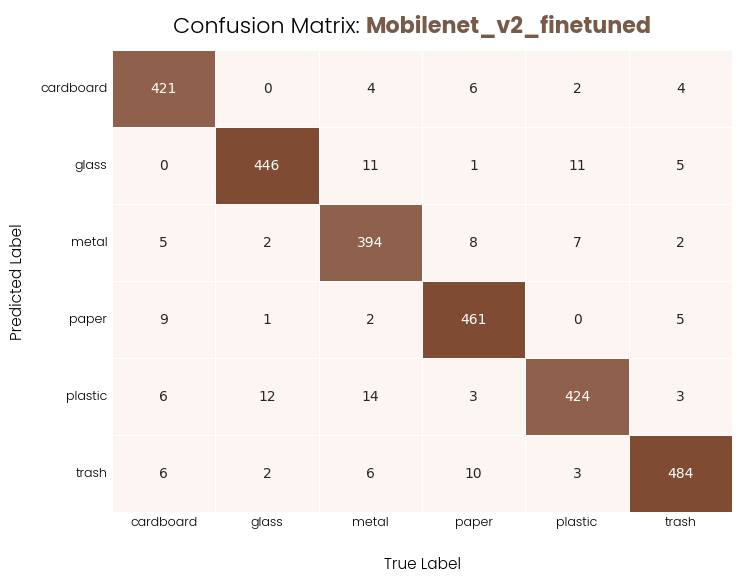


--- Detailed Classification Report: mobilenet_v2_finetuned ---
              precision    recall  f1-score   support

   cardboard       0.94      0.96      0.95       437
       glass       0.96      0.94      0.95       474
       metal       0.91      0.94      0.93       418
       paper       0.94      0.96      0.95       478
     plastic       0.95      0.92      0.93       462
       trash       0.96      0.95      0.95       511

    accuracy                           0.95      2780
   macro avg       0.95      0.95      0.95      2780
weighted avg       0.95      0.95      0.95      2780


🏆 FINAL EXPERIMENT RESULTS 🏆


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,control,0.7626,0.7658,0.7649,0.7633
1,shallow,0.6878,0.6882,0.6903,0.6870
2,vgg_style,0.7493,0.7524,0.7528,0.7475
3,large_kernel,0.7619,0.7667,0.7635,0.7621
4,mobilenet_v2,0.9079,0.9077,0.9081,0.9076
5,mobilenet_v2_finetuned,0.9460,0.9455,0.9460,0.9456


In [8]:
# Extract validation data ONCE so it is perfectly consistent for all models
print("Extracting validation images and labels...")
val_images = []
val_labels = []
for images, labels in val_ds.unbatch():
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.array(val_images)
val_labels = np.array(val_labels)
print(f"Loaded {len(val_images)} validation images.")

# List the models
architectures_to_evaluate = [
    'control', 
    'shallow', 
    'vgg_style', 
    'large_kernel', 
    'mobilenet_v2',
    'mobilenet_v2_finetuned'
]
all_metrics = []

# Loop through, rebuild, load, and evaluate
for arch in architectures_to_evaluate:
    print(f"\n{'='*50}")
    print(f"🔍 EVALUATING: {arch.capitalize()}")
    print(f"{'='*50}")
    
    keras.backend.clear_session() 
    
    # A. Build the empty "brain" 
    model = build_experimental_model(arch, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), augmentation=False)
    
    # B. Define where the weights file is saved
    weights_path = f'../models/{arch}_best.weights.h5'
    
    if os.path.exists(weights_path):
        # C. Load the "memories" into the model
        model.load_weights(weights_path)
        print(f"Successfully loaded weights for {arch}.")
        
        # D. Make predictions
        print("Generating predictions...")
        predictions = model.predict(val_images)
        predicted_classes = np.argmax(predictions, axis=1)
        
        # E. Run evaluation function
        metrics_df = evaluate_and_plot(
            y_true=val_labels, 
            y_pred=predicted_classes, 
            class_names=CLASSES, 
            model_name=arch
        )
        all_metrics.append(metrics_df)
    else:
        print(f"⚠️ Warning: Could not find weights at {weights_path}. Skipping.")

# Combine all the metrics into one final table
if all_metrics:
    final_results_df = pd.concat(all_metrics, ignore_index=True)
    
    print("\n🏆 FINAL EXPERIMENT RESULTS 🏆")
    display(final_results_df)
    
    # Save this final table to a CSV
    final_results_df.to_csv('../logs/final_metrics_comparison.csv', index=False)

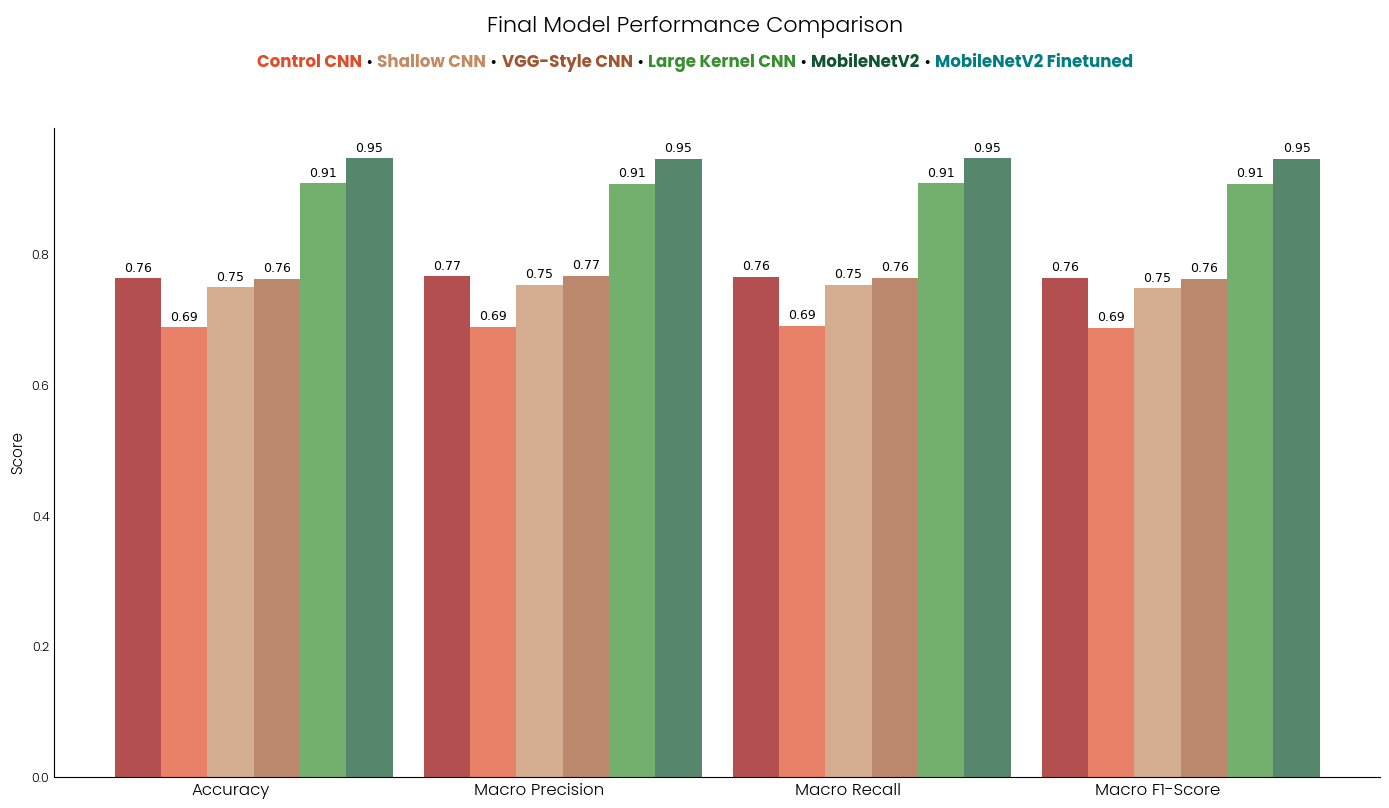

In [9]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(pd.read_csv('../logs/final_metrics_comparison.csv'))

# Setup the chart layout
metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']
models = df['Model'].tolist()

# Define positions for the groups
x = np.arange(len(metrics))  
bar_width = 0.15  # Width of each individual bar

fig, ax = plt.subplots(figsize=(14, 8))

# Plot each model's bars
for i, model_name in enumerate(models):
    # Get the scores for this specific model across all metrics
    scores = df[df['Model'] == model_name][metrics].values[0]
    
    # Calculate the offset for this specific bar
    offset = (i - 2) * bar_width 
    
    bars = ax.bar(x + offset, scores, bar_width, label=model_name, color=cmap(i), alpha=0.7)
    
    # Add the text labels on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
style_plot_fonts(ax)
fig_text(
        x=0.5, y=0.97,            
        ha='center', va='bottom', 
        s=f"Final Model Performance Comparison", 
        fontsize=title_fontsize, 
        fontproperties=poppins_light,
        ax=ax
    )

# 2. SUBTITLE (Replacing the legend)
fig_text(
    x=0.5, y=0.95,
    ha='center', 
    s="<Control CNN> • <Shallow CNN> • <VGG-Style CNN> • <Large Kernel CNN> • <MobileNetV2> • <MobileNetV2 Finetuned>",
    fontsize=12,
    fontproperties=poppins_light,
    highlight_textprops=[
        {"color": cmap(1), "fontproperties": poppins_bold}, # Maps to <Control CNN>
        {"color": cmap(2), "fontproperties": poppins_bold}, # Maps to <Shallow CNN>
        {"color": cmap(3), "fontproperties": poppins_bold}, # Maps to <VGG-Style CNN>
        {"color": cmap(4), "fontproperties": poppins_bold}, # Maps to <Large Kernel CNN>
        {"color": cmap(5), "fontproperties": poppins_bold}, # Maps to <MobileNetV2>
        {"color": cmap(6), "fontproperties": poppins_bold}  # Maps to <MobileNetV2 Finetuned>
    ],
    ax=ax                     
)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)

plt.tight_layout()
plt.savefig('../plots/final_metrics_comparison.png', bbox_inches='tight')
plt.show()